# Property Scanner: Multimodal AI Valuation System

## 1. Project Overview
**Objective**: Predict property prices in Spanish cities (Madrid, Barcelona, etc.) using a **Multimodal Late-Fusion Model**.

**Key Innovation**: Unlike traditional comparable approaches that only use numbers (sqm, rooms), this system "sees" the property using a **Vision Language Model (VLM)** to extract qualitative features (condition, style, finishes) from images and fuses them with quantitative data.


## 2. System Architecture

The system uses a state-of-the-art **Agentic Pipeline** to transform raw web data into reasoned valuations.

### Pipeline Stages:
1.  **Extraction Agent**: Scrapes and normalizes raw data into `CanonicalListing` objects.
2.  **Vision Agent (VLM)**: Deep-inspects photos using **Llava/Ollama** to describe interiors and finishes.
3.  **Embedding Engine**: Converts text and descriptions into **384D vectors** via SentenceTransformers.
4.  **Fusion Model**: A custom PyTorch model that performs **Cross-Attention** between the target property and local market comparables.


## 3. Data Inspection

Let's look at the data collected in `data/listings.db`.

In [8]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import ast
import json
import seaborn as sns
import sys
import os

# Ensure we can import from src
sys.path.append('..')

# Connect to Database
conn = sqlite3.connect('../data/listings.db')
df = pd.read_sql_query("SELECT * FROM listings WHERE price > 0", conn)
conn.close()

print(f"Total Listings: {len(df)}")
display(df.head())

Total Listings: 0


,id,source_id,external_id,url,title,description,price,currency,property_type,bedrooms,...,image_urls,vlm_description,sentiment_score,analysis_meta,tags,listed_at,updated_at,fetched_at,status,sold_at


### 3.1 Market Composition: City Breakdown
Where is our data coming from? We've expanded to include the most active real estate markets in Spain.

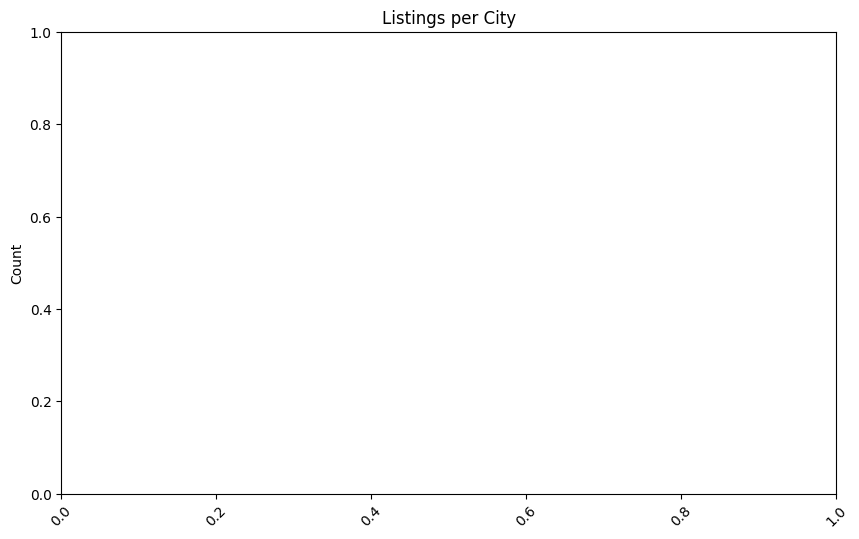

In [2]:
plt.figure(figsize=(10, 6))
city_counts = df['city'].value_counts()[:10]
sns.barplot(x=city_counts.index, y=city_counts.values, palette='viridis')
plt.title('Listings per City')
plt.xticks(rotation=45)
plt.ylabel('Count')
plt.show()

### 3.2 Geospatial Analysis
Visualizing the spatial density of our properties.

In [3]:
import plotly.express as px
import plotly.graph_objects as go

# Filter out valid coordinates
geo_df = df[(df['lat'] != 0) & (df['lon'] != 0)]

# Major Cities for Reference
cities_data = {
    'City': ['Madrid', 'Barcelona', 'Valencia', 'Seville', 'Zaragoza', 'Málaga'],
    'Lat': [40.4168, 41.3851, 39.4699, 37.3891, 41.6488, 36.7212],
    'Lon': [-3.7038, 2.1734, -0.3763, -5.9845, -0.8891, -4.4214]
}
cities_df = pd.DataFrame(cities_data)

# Create Plotly Map with Satellite Background (Esri)
fig = px.scatter_mapbox(geo_df, lat='lat', lon='lon', color='price',
                        color_continuous_scale='Viridis', size_max=15, zoom=5, height=600,
                        hover_data=['price', 'city'], title='Property Distribution (Satellite View)')

# Add City Labels
fig.add_trace(go.Scattermapbox(
    lat=cities_df['Lat'],
    lon=cities_df['Lon'],
    mode='markers+text',
    marker=go.scattermapbox.Marker(size=12, color='red'),
    text=cities_df['City'],
    textposition='top right',
    name='Major Cities'
))

# Update layout to use Esri World Imagery (Satellite) tiles
fig.update_layout(
    mapbox_style="white-bg",
    mapbox_layers=[
        {
            "below": 'traces',
            "sourcetype": "raster",
            "sourceattribution": "Esri, Maxar, Earthstar Geographics",
            "source": [
                "https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}"
            ]
        }
    ],
    margin={"r":0,"t":40,"l":0,"b":0}
)
fig.show()

/var/folders/dc/xp5rn2p562g61yp_f0n6mxl40000gn/T/ipykernel_84847/737516324.py:16: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(geo_df, lat='lat', lon='lon', color='price',
/var/folders/dc/xp5rn2p562g61yp_f0n6mxl40000gn/T/ipykernel_84847/737516324.py:21: DeprecationWarning:

*scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/



### 3.3 Data Quality Analysis

Understanding data completeness is crucial. The chart below visualizes the percentage of missing values for each feature in our dataset.

In [4]:
# Connect to Database to get full dataset
conn = sqlite3.connect('../data/listings.db')
quality_df = pd.read_sql_query("SELECT * FROM listings", conn)
conn.close()

# Calculate missing percentages
missing_props = quality_df.isnull().sum() / len(quality_df) * 100
# Filter properties that actually have missing data
missing_props = missing_props[missing_props > 0].sort_values(ascending=False)

if not missing_props.empty:
    # Visualize
    plt.figure(figsize=(10, 8))
    sns.barplot(x=missing_props.values, y=missing_props.index, palette='magma')
    plt.title('Percentage of Missing Data by Feature')
    plt.xlabel('Percentage Missing (%)')
    plt.ylabel('Feature')
    plt.grid(axis='x', linestyle='--', alpha=0.6)

    # Add value labels
    for i, v in enumerate(missing_props.values):
        plt.text(v + 0.5, i, f"{v:.1f}%", va='center')
    
    plt.tight_layout()
    plt.show()
else:
    print("Amazing! No missing data found in the dataset.")

Amazing! No missing data found in the dataset.


## 4. VLM: The Visual Intelligence

Traditional models miss detail. Our VLM captures descriptions like *"modern open-concept kitchen"* or *"ranch-style villa with pool"*.

In [5]:
vlm_enriched = df[df['vlm_description'].notna() & (df['vlm_description'] != '')]
print(f"Enriched Listings: {len(vlm_enriched)}")

if not vlm_enriched.empty:
    sample = vlm_enriched.sample(1).iloc[0]
    print(f"\nProperty: {sample['title']}")
    print("VLM Insight:", sample['vlm_description'][:400] + "...")

Enriched Listings: 0


## 5. Model Training & Performance

Below is the current training convergence for the **92k-parameter compact model**.

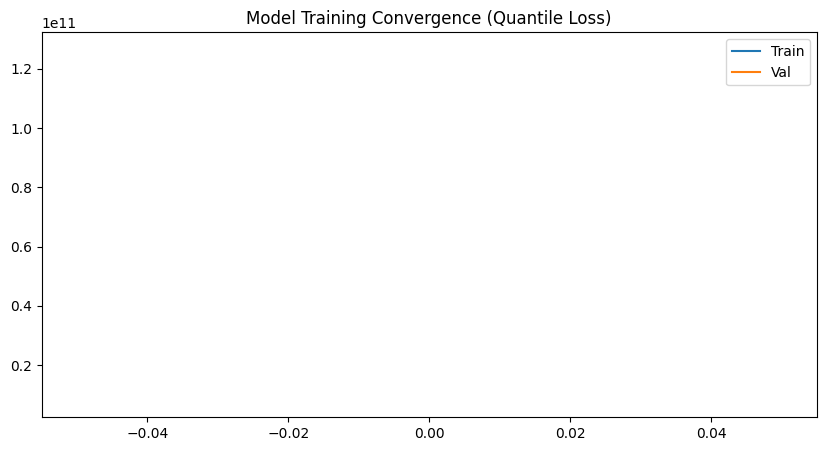

In [6]:
import torch
import matplotlib.pyplot as plt
checkpoint_path = '../models/checkpoint_latest.pt'
if os.path.exists(checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location='cpu')
    plt.figure(figsize=(10, 5))
    plt.plot(ckpt['train_losses'], label='Train')
    plt.plot(ckpt['val_losses'], label='Val')
    plt.title('Model Training Convergence (Quantile Loss)')
    plt.legend()
    plt.show()
else:
    print("Checkpoint not found. Run training first.")

## 6. Live Inference Example

Compare the AI's valuation with the actual market price.

In [7]:
from src.training.dataset import PropertyDataset, collate_fn
from src.services.fusion_model import PropertyFusionModel
import torch
import numpy as np

# Set up dataset and sample
ds = PropertyDataset(db_path='../data/listings.db', use_vlm=True)
idx = np.random.randint(0, len(ds))
item = ds[idx]
batch = collate_fn([item])

# Load Model
model = PropertyFusionModel(hidden_dim=64, num_heads=2) # Compact settings
if os.path.exists('../models/fusion_model.pt'):
    model.load_state_dict(torch.load('../models/fusion_model.pt', map_location='cpu'))
    model.eval()
    with torch.no_grad():
        q, _, _, _ = model(
            target_tab=batch['target_tab'], 
            target_text=batch['target_text'],
            comp_tab=batch['comp_tab'], 
            comp_text=batch['comp_text'], 
            comp_prices=batch['comp_prices'],
            target_image=None,
            comp_image=None
        )
        
    actual = batch['target_price'][0].item()
    pred = q[0, 1].item()
    print(f"Title: {ds.listings[idx]['title']}")
    print(f"Actual: €{actual:,.0f} | Predicted: €{pred:,.0f} | Error: {abs(actual-pred)/actual*100:.1f}%")
else:
    print("Model weights not found. Prediction skipped.")

2026-01-13 23:13:19 [info     ] text_encoder_initialized       dim=384 model=all-MiniLM-L6-v2
2026-01-13 23:13:19 [info     ] dataset_initialized            db_path=../data/listings.db num_cities=0 num_listings=0 price_range=(10000, 15000000) vlm_enabled=True
2026-01-13 23:13:19 [info     ] tabular_encoder_fitted         features=10
2026-01-13 23:13:19 [info     ] tabular_encoder_fitted         num_samples=0


ValueError: high <= 0

### 3.4 Data Cleaning: Outlier Removal

To ensure data quality, we remove records with values that are physically impossible or highly improbable (e.g., extreme prices, invalid floors).

In [ ]:
# Simple Cleaner Logic
original_count = len(df)

# Define sensible bounds for our features
guards = {
    'price': {'min': 10000, 'max': 10000000},
    'floor': {'min': -5, 'max': 70},
    'surface_area_sqm': {'min': 10, 'max': 5000},
    'bedrooms': {'min': 0, 'max': 25},
    'bathrooms': {'min': 0, 'max': 20}
}

print(f"Starting Data Cleaning (Rows: {original_count})...")

for col, bounds in guards.items():
    if col in df.columns:
        # Filter outliers
        mask = (df[col] < bounds['min']) | (df[col] > bounds['max'])
        n_dropped = mask.sum()
        if n_dropped > 0:
            print(f" - Removing {n_dropped} outliers in '{col}' (Allowed: {bounds['min']} - {bounds['max']})")
            df = df[~mask]

print(f"Cleaning Complete. Final Rows: {len(df)} (Total Removed: {original_count - len(df)})")

Starting Data Cleaning (Rows: 2443)...
 - Removing 88 outliers in 'price' (Allowed: 10000 - 10000000)
 - Removing 21 outliers in 'floor' (Allowed: -5 - 70)
 - Removing 106 outliers in 'surface_area_sqm' (Allowed: 10 - 5000)
Cleaning Complete. Final Rows: 2228 (Total Removed: 215)


### 3.5 Feature Distributions

Let's create violin plots for all numerical features to understand their distributions.

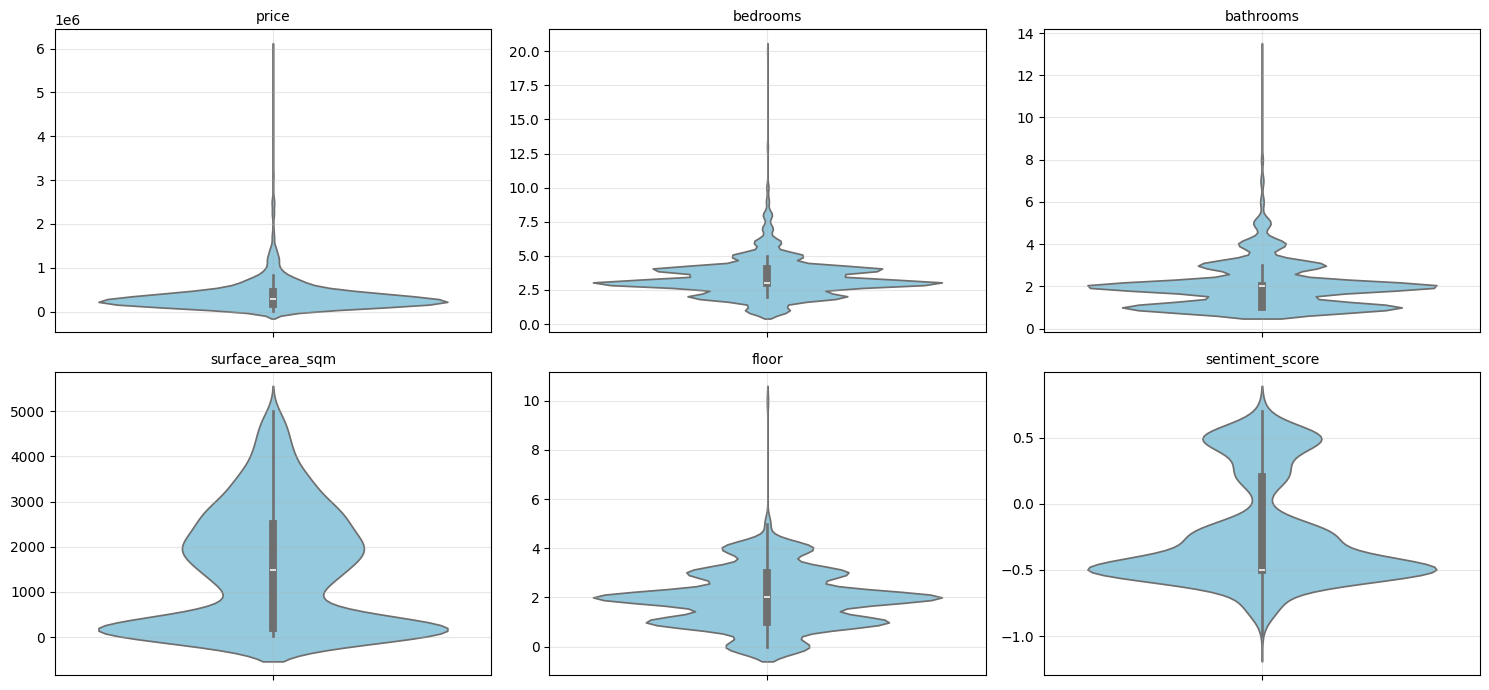

In [ ]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=['number']).columns

# Exclude boolean-like or specific columns that don't make sense for violin plots
exclude_cols = ['has_elevator', 'lat', 'lon'] 
numeric_cols = [c for c in numeric_cols if c not in exclude_cols]

# Set up a more compact plotting layout
n_cols = 3  # Increased columns for compactness
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

# Reduced height multiplier to make it more compact vertically
plt.figure(figsize=(15, 3.5 * n_rows))

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.violinplot(y=df[col], color='skyblue')
    plt.title(f'{col}', fontsize=10)
    plt.ylabel('') # Remove y-label to save space, usually title is enough
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 3.3 VLM Description Coverage
Analysis of how many listings have Vision Language Model descriptions generated from images.


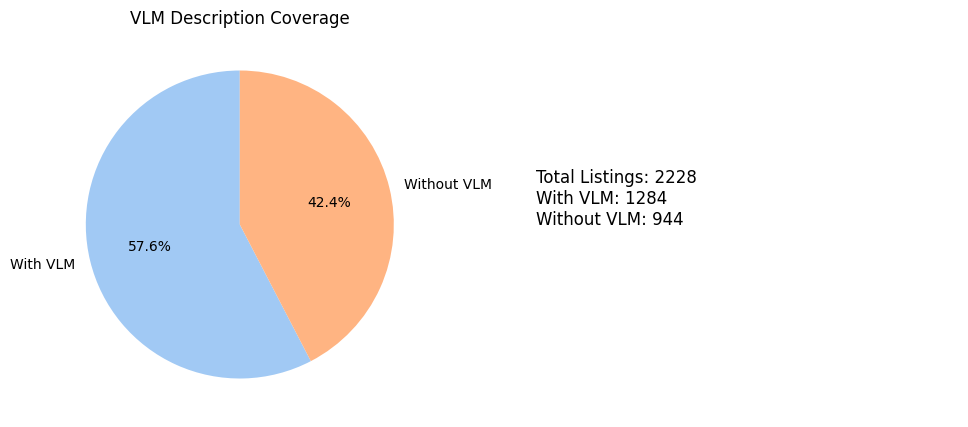


--- 4 Random VLM Description Examples ---

Example 1:
 1. Room type: The property is a single-family home with an attached garage, as visible by the presence of the white door.
2. Condition: The exterior appears to be in a renovated or well-maintained condition; there's no clear indication of any immediate need for renovation, but it does look like a t...

Example 2:
 The image depicts a multi-story apartment building. Based on the visual information provided:

1. Room Type: The building appears to have multiple residential units with varying room sizes and configurations. There are visible windows indicating potential living rooms or bedrooms. Kitchens may be p...

Example 3:
 The image depicts an exterior view of a property that appears to be a combination of living space and kitchen. The overall condition of the property is in good shape, suggesting it has been well-maintained or recently renovated. Quality-wise, it seems to be a modern property with a luxury feel due ...

Example 

In [ ]:
# VLM Statistics
vlm_mask = df['vlm_description'].apply(lambda x: x is not None and str(x) != 'None' and len(str(x)) > 10)
vlm_counts = vlm_mask.value_counts()
vlm_counts.index = ['With VLM', 'Without VLM'] if vlm_counts.index[0] == True else ['Without VLM', 'With VLM']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
colors = sns.color_palette('pastel')[0:2]
plt.pie(vlm_counts, labels=vlm_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('VLM Description Coverage')

plt.subplot(1, 2, 2)
plt.axis('off')
plt.text(0, 0.5, f'Total Listings: {len(df)}\nWith VLM: {vlm_mask.sum()}\nWithout VLM: {len(df) - vlm_mask.sum()}', fontsize=12)
plt.show()

print('\n--- 4 Random VLM Description Examples ---')
if vlm_mask.sum() > 0:
    for i, desc in enumerate(df[vlm_mask]['vlm_description'].sample(min(4, vlm_mask.sum())).values):
        print(f'\nExample {i+1}:\n{desc[:300]}...')


### 3.4 Text Description Coverage
Analysis of standard text descriptions provided in the listings.


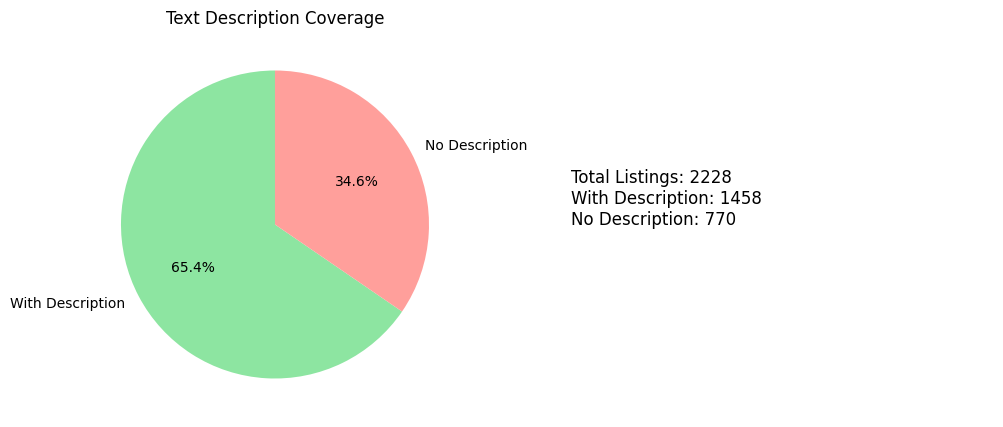


--- 4 Random Text Description Examples ---

Example 1:
ATICO, con TERRAZA, y GARAJE, a un paso del Paseo Zorrilla, cuenta un amplio hall de entrada, 4 dormitorios, salón, cocina amueblada y galería cubierta y 2 baños completos que se reformaron hace unos años. Exterior con muy buenas vistas. Posibilidad de una segunda plaza de garaje en alquiler. La cal...

Example 2:
¡Descubre este increíble piso en pleno corazón de Valladolid! Con una ubicación privilegiada, a solo 5 minutos de la Plaza Mayor y a 3 minutos de la Plaza España, este inmueble ofrece una oportunidad única para crear el hogar de tus sueños. Con aproximadamente 86 m² útiles, esta vivienda cuenta con ...

Example 3:
Casa en venta, para rehabilitar, ubicada en el municipio de Villanueva de Gállego, en una parcela de aproximadamente 200m2. Cuenta con una distribución de una sola planta en vivienda y almacén, además de un jardín con una superficie de unos 35m2. Se encuentra próxima a centros educativos y parques. ...

Example

In [ ]:
# LLM/Text Statistics
text_mask = df['description'].apply(lambda x: x is not None and str(x) != 'None' and len(str(x)) > 10)
text_counts = text_mask.value_counts()
text_counts.index = ['With Description', 'No Description'] if text_counts.index[0] == True else ['No Description', 'With Description']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
colors = sns.color_palette('pastel')[2:4]
plt.pie(text_counts, labels=text_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Text Description Coverage')

plt.subplot(1, 2, 2)
plt.axis('off')
plt.text(0, 0.5, f'Total Listings: {len(df)}\nWith Description: {text_mask.sum()}\nNo Description: {len(df) - text_mask.sum()}', fontsize=12)
plt.show()

print('\n--- 4 Random Text Description Examples ---')
if text_mask.sum() > 0:
    for i, desc in enumerate(df[text_mask]['description'].sample(min(4, text_mask.sum())).values):
        print(f'\nExample {i+1}:\n{desc[:300]}...')
